In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import numpy as np
import scienceplots
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from scipy.stats import linregress
%matplotlib inline

# ---------------------------------------------------------------------------
#  Matplotlib Styles
# ---------------------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "pdf.fonttype": 42,

   })

# ---------------------------------------------------------------------------
#  Load Data
# ---------------------------------------------------------------------------

EXCEL_PATH= r"C:\Users\mouly\Dropbox\Codes and Dataset\Field_Horizontal.xlsx"
INSET_EXCEL_PATH = r"C:\Users\mouly\Dropbox\Codes and Dataset\Field_Horizontal.xlsx"

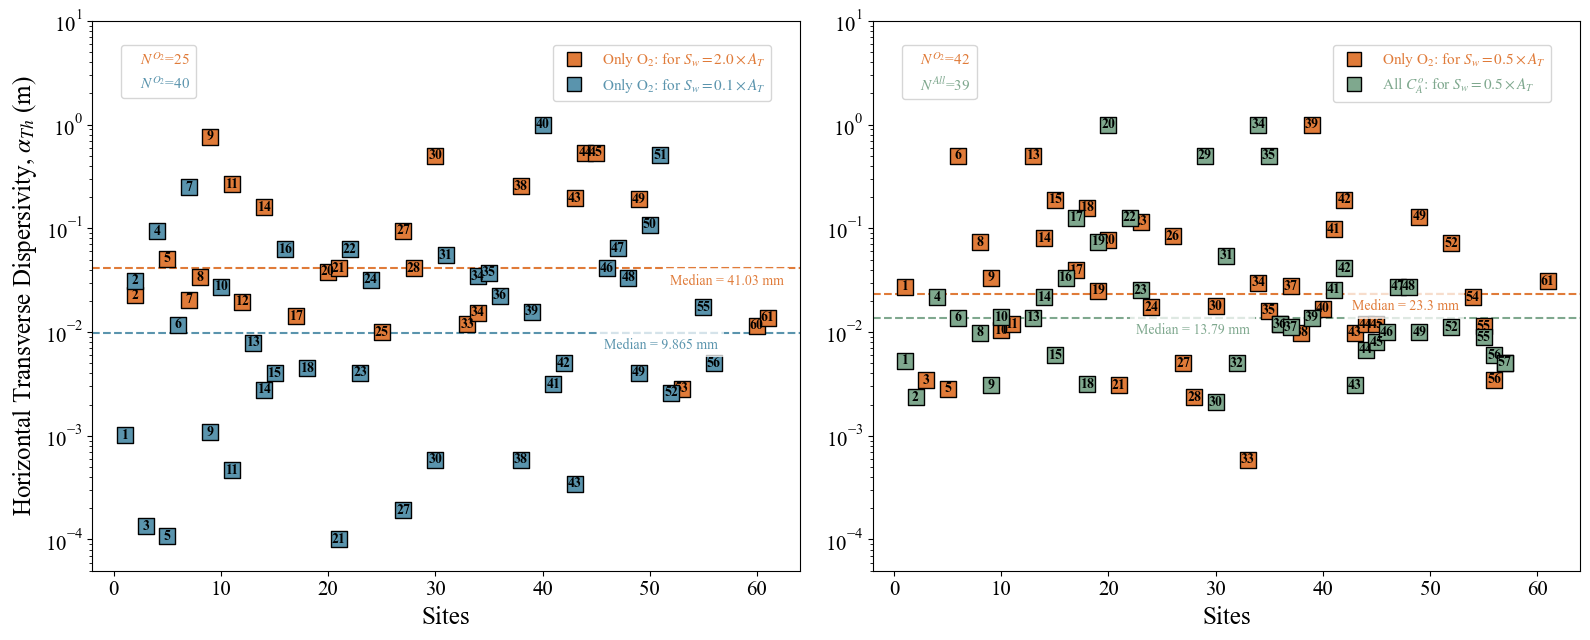

In [7]:
# ---------------------------------------------------------------------------
# Load & Clean
# ---------------------------------------------------------------------------
def clean(df):
    df["Site_ID"] = pd.to_numeric(df["Site_ID"], errors="coerce")
    df["ath"] = pd.to_numeric(df["ath"], errors="coerce")
    df = df.dropna(subset=["Site_ID", "ath"]).reset_index(drop=True)
    df["Site_ID"] = df["Site_ID"].astype(int)
    return df


df_20 = clean(pd.read_excel(EXCEL_PATH, sheet_name="2.0_O2"))
df_01 = clean(pd.read_excel(EXCEL_PATH, sheet_name="0.1_O2"))
df_05_O2 = clean(pd.read_excel(EXCEL_PATH, sheet_name="0.5_O2"))
df_05_All = clean(pd.read_excel(EXCEL_PATH, sheet_name="0.5_All"))


# ---------------------------------------------------------------------------
#   - scatter the points + label each with its Site_ID
#   - draw a dashed median line
#   - write the "Median = ..." text box
# ---------------------------------------------------------------------------
def scatter_with_median(ax, df, color, marker, x_text_frac, y_text_frac, xmax):
    ax.scatter(df["Site_ID"], df["ath"], color=color, edgecolors="k",
               s=120, marker=marker, zorder=3)

    for _, row in df.iterrows():
        ax.text(row["Site_ID"], row["ath"], str(int(row["Site_ID"])),
                 ha="center", va="center", fontweight="bold", color="black")

    median = df["ath"].median()
    ax.axhline(median, color=color, linestyle="--", linewidth=1.5)
    ax.text(xmax * x_text_frac, median * y_text_frac, f"Median = {median * 1000:.4g} mm",
             color=color, bbox=dict(facecolor="white", edgecolor="none", alpha=0.75))

    return median


# Small helper to build the two legends (color-coded labels, top-left and top-right)
def add_legends(ax, right_labels_colors, left_labels_colors):
    right_handles = [
        mlines.Line2D([], [], color=c, marker="s", markeredgecolor="k",
                      linestyle="None", markersize=10, label=lbl)
        for lbl, c in right_labels_colors
    ]
    leg_right = ax.legend(handles=right_handles, loc="upper right",
                           bbox_to_anchor=(0.97, 0.97))
    for text, (_, c) in zip(leg_right.get_texts(), right_labels_colors):
        text.set_color(c)
    ax.add_artist(leg_right)

    left_handles = [
        mlines.Line2D([], [], marker="None", linestyle="None", label=lbl)
        for lbl, _ in left_labels_colors
    ]
    leg_left = ax.legend(handles=left_handles, loc="upper left",
                          bbox_to_anchor=(0.03, 0.97), handlelength=0)
    for text, (_, c) in zip(leg_left.get_texts(), left_labels_colors):
        text.set_color(c)


# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))

# LEFT PANEL: 2.0_O2 vs 0.1_O2
xmax1 = max(df_20["Site_ID"].max(), df_01["Site_ID"].max())
scatter_with_median(ax1, df_20, "#E07B39", "s", 0.85, 0.7, xmax1)
scatter_with_median(ax1, df_01, "#5A94AD", "s", 0.75, 0.7, xmax1)

ax1.set_yscale("log")
ax1.set_ylim(5e-5, 10)
ax1.set_xlabel("Sites",fontsize=18)
ax1.set_ylabel(r"Horizontal Transverse Dispersivity, $\alpha_{Th}$ (m)",fontsize=18)
ax1.tick_params(axis="both", which="both", labelsize=15)
add_legends(
    ax1,
    right_labels_colors=[
        (rf"Only O$_2$: for $S_w=2.0\times A_T$", "#E07B39"),
        (rf"Only O$_2$: for $S_w=0.1\times A_T$", "#5A94AD"),
    ],
    left_labels_colors=[
        (rf"$N^{{O_2}}$={df_20['Site_ID'].nunique()}", "#E07B39"),
        (rf"$N^{{O_2}}$={df_01['Site_ID'].nunique()}", "#5A94AD"),
    ],
)

# RIGHT PANEL: 0.5_O2 vs 0.5_All
xmax2 = max(df_05_O2["Site_ID"].max(), df_05_All["Site_ID"].max())
scatter_with_median(ax2, df_05_O2, "#E07B39", "s", 0.70, 0.7, xmax2)
scatter_with_median(ax2, df_05_All, "#7FA88E", "s", 0.37, 0.7, xmax2)

ax2.set_yscale("log")
ax2.set_ylim(5e-5, 10)
ax2.set_xlabel("Sites", fontsize=18)
ax2.tick_params(axis="both", which="both", labelsize=15)
add_legends(
    ax2,
    right_labels_colors=[
        (rf"Only O$_2$: for $S_w=0.5\times A_T$", "#E07B39"),
        (rf"All $C_A^o$: for $S_w=0.5\times A_T$", "#7FA88E"),
    ],
    left_labels_colors=[
        (rf"$N^{{O_2}}$={df_05_O2['Site_ID'].nunique()}", "#E07B39"),
        (rf"$N^{{All}}$={df_05_All['Site_ID'].nunique()}", "#7FA88E"),
    ],
)

# ---------------------------------------------------------------------------
# Save and show
# ---------------------------------------------------------------------------
plt.tight_layout()
plt.savefig("fig6.pdf", dpi=300, bbox_inches="tight")
plt.show()

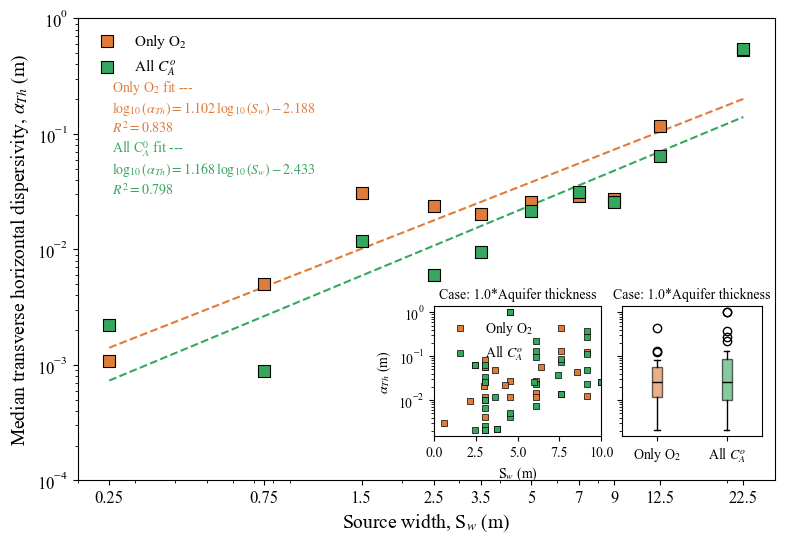

---- Only O2 ----
log10(alpha_Th) = 1.1025 x log10(t) - 2.1880
R^2 = 0.8379

---- All compounds ----
log10(alpha_Th) = 1.1676 x log10(t) - 2.4327
R^2 = 0.7985



In [12]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
PHIS = ["0.1", "0.25", "0.5", "0.75", "1.0", "1.5", "2.0"]

COLOR_O2  = "#E07B39"
COLOR_ALL = "#36A75F"

# EXCEL_PATH = "Field_Horizontal_26_07.xlsx"
# INSET_EXCEL_PATH = "Field_Horizontal_26_07.xlsx"


SELECTED_PHI = "1.0"          
XLIM_MAX = 10
INSET_X_COL = "st"
INSET_Y_COL = "ath"


# ---------------------------------------------------------------------------
# Step 1: Load + clean data
# ---------------------------------------------------------------------------
def clean(df, cols):
    df = df.copy()
    for col in cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.dropna(subset=cols).reset_index(drop=True)


df_o2  = clean(pd.concat([pd.read_excel(EXCEL_PATH, sheet_name=f"{p}_O2")  for p in PHIS], ignore_index=True),
               ["st", "ath"])
df_all = clean(pd.concat([pd.read_excel(EXCEL_PATH, sheet_name=f"{p}_All") for p in PHIS], ignore_index=True),
               ["st", "ath"])


# ---------------------------------------------------------------------------
# Step 2: Bin into thickness bands, get median alpha per band
# ---------------------------------------------------------------------------
# NOTE: last edge extended 26 -> 30 to capture the max observed "st" (30.0)
# in the "All" sheets; with 26 that point was silently dropped by pd.cut.
bins   = [0, 0.5, 1, 2, 3, 4, 6, 8, 10, 15, 30]
labels = ["0-0.5", "0.5-1", "1-2", "2-3", "3-4", "4-6", "6-8", "8-10", "10-15", "15-30"]

# Fixed bin midpoints (matches the vertical/reference script's approach:
# x-position AND tick label = arithmetic center of the bin, not the raw
# median of the data within that bin).
bin_centers = [(bins[i] + bins[i + 1]) / 2 for i in range(len(bins) - 1)]
band_center = dict(zip(labels, bin_centers))


def band_medians(df):
    df = df.copy()
    df["band"] = pd.cut(df["st"], bins=bins, labels=labels, right=True)
    r_vals, median_vals = [], []
    for band in labels:
        subset = df[df["band"] == band]
        if len(subset) > 0:
            r_vals.append(band_center[band])
            median_vals.append(subset["ath"].median())
    return np.array(r_vals), np.array(median_vals)


r_o2, median_o2 = band_medians(df_o2)
r_all, median_all = band_medians(df_all)


# ---------------------------------------------------------------------------
# Step 3: Linear fit in log-log space -> log10(alpha) = m*log10(t) + c
# ---------------------------------------------------------------------------
def fit_and_curve(r, median):
    m, c, r_value, p_value, std_err = linregress(np.log10(r), np.log10(median))
    r_fit = np.logspace(np.log10(r.min()), np.log10(r.max()), 200)
    fit = (10**c) * r_fit**m
    return m, c, r_value, r_fit, fit


m_o2, c_o2, r_o2_val, r_fit_o2, fit_o2 = fit_and_curve(r_o2, median_o2)
m_all, c_all, r_all_val, r_fit_all, fit_all = fit_and_curve(r_all, median_all)


# ---------------------------------------------------------------------------
# Step 4: Load raw phi=1.0 data for the inset plots (skipped-cases rows
# are dropped the same way as above, via clean())
# ---------------------------------------------------------------------------
def load_inset(sheet_name):
    df = pd.read_excel(INSET_EXCEL_PATH, sheet_name=sheet_name)[[INSET_X_COL, INSET_Y_COL]]
    return clean(df, [INSET_X_COL, INSET_Y_COL])


inset_o2  = load_inset(f"{SELECTED_PHI}_O2")
inset_all = load_inset(f"{SELECTED_PHI}_All")
inset_o2  = inset_o2[inset_o2[INSET_X_COL] <= XLIM_MAX]
inset_all = inset_all[inset_all[INSET_X_COL] <= XLIM_MAX]


# ---------------------------------------------------------------------------
# Step 5: Main plot
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(r_o2, median_o2, s=85, marker="s", color=COLOR_O2, edgecolors="black", linewidths=0.8,
           label="Only O$_2$", zorder=3)
ax.plot(r_fit_o2, fit_o2, "--", color=COLOR_O2, linewidth=1.5)

ax.scatter(r_all, median_all, s=85, marker="s", color=COLOR_ALL, edgecolors="black", linewidths=0.8,
           label="All $C_A^o$", zorder=3)
ax.plot(r_fit_all, fit_all, "--", color=COLOR_ALL, linewidth=1.5)

# Equation annotations
sign_o2  = "+" if c_o2  >= 0 else "-"
sign_all = "+" if c_all >= 0 else "-"

ax.text(0.05, 0.87,
        r"Only O$_2$ fit ---" "\n"
        rf"$\log_{{10}}(\alpha_{{Th}}) = {m_o2:.3f}\,\log_{{10}}(S_w) {sign_o2} {abs(c_o2):.3f}$" "\n"
        rf"$R^2 = {r_o2_val**2:.3f}$",
        transform=ax.transAxes, color=COLOR_O2, va="top",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.95, pad=2))

ax.text(0.05, 0.74,
        r"All C$_A^0$ fit ---" "\n"
        rf"$\log_{{10}}(\alpha_{{Th}}) = {m_all:.3f}\,\log_{{10}}(S_w) {sign_all} {abs(c_all):.3f}$" "\n"
        rf"$R^2 = {r_all_val**2:.3f}$",
        transform=ax.transAxes, color=COLOR_ALL, va="top",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.95, pad=2))

# ---------------------------------------------------------------------------
# Axes formatting - LOG-LOG, ticks at fixed bin midpoints 
# ---------------------------------------------------------------------------
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(bin_centers)
ax.set_xticklabels([f"{c:g}" for c in bin_centers], rotation=0, ha="center")
ax.set_xlabel("Source width, S$_w$ (m)",fontsize=14)
ax.set_ylabel(r"Median transverse horizontal dispersivity, $\alpha_{Th}$ (m)",fontsize=14)
ax.legend(loc="upper left", frameon=False)
ax.set_ylim(1e-4, 1e0)

# ---------------------------------------------------------------------------
# Step 6: Inset scatter + inset boxplot for phi = 1.0
# ---------------------------------------------------------------------------
ax_scatter = inset_axes(ax, width="24%", height="28%",
                         bbox_to_anchor=(0.50, 0.08, 1, 1),
                         bbox_transform=ax.transAxes, loc="lower left")
ax_scatter.scatter(inset_o2[INSET_X_COL], inset_o2[INSET_Y_COL], s=20, marker="s", color=COLOR_O2,
                    edgecolors="black", linewidths=0.5, label="Only O$_2$")
ax_scatter.scatter(inset_all[INSET_X_COL], inset_all[INSET_Y_COL], s=20, marker="s", color=COLOR_ALL,
                    edgecolors="black", linewidths=0.5, label="All $C_A^o$")
ax_scatter.set_yscale("log")
ax_scatter.set_xlim(0, XLIM_MAX)
ax_scatter.set_xlabel("S$_w$ (m)", fontsize=10)
ax_scatter.set_ylabel(r"$\alpha_{Th}$ (m)", fontsize=10)
ax_scatter.set_title(rf"Case: {SELECTED_PHI}*Aquifer thickness", fontsize=10)
ax_scatter.tick_params(labelsize=10)
ax_scatter.legend(fontsize=10, loc="best", frameon=False)

ax_box = inset_axes(ax, width="20%", height="28%",
                     bbox_to_anchor=(0.77, 0.08, 1, 1),
                     bbox_transform=ax.transAxes, loc="lower left")
bp = ax_box.boxplot([inset_o2[INSET_Y_COL], inset_all[INSET_Y_COL]],
                     tick_labels=["Only O$_2$", "All $C_A^o$"],
                     patch_artist=True, medianprops=dict(color="black"))
for patch, color in zip(bp["boxes"], [COLOR_O2, COLOR_ALL]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax_box.set_yscale("log")
ax_box.tick_params(axis="y", which="both", labelleft=False, left=True)
ax_box.tick_params(axis="x", labelsize=10)
ax_box.set_title(rf"Case: {SELECTED_PHI}*Aquifer thickness", fontsize=10)
ax_box.tick_params(labelsize=10)

plt.savefig("fig7.pdf", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------------------
# Step 7: Print results
# ---------------------------------------------------------------------------
for name, m, c, rv in [("Only O2", m_o2, c_o2, r_o2_val), ("All compounds", m_all, c_all, r_all_val)]:
    print(f"---- {name} ----")
    print(f"log10(alpha_Th) = {m:.4f} x log10(t) {'+' if c >= 0 else '-'} {abs(c):.4f}")
    print(f"R^2 = {rv**2:.4f}\n")